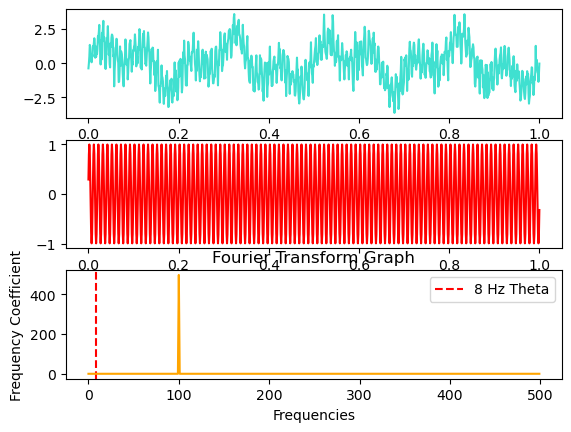

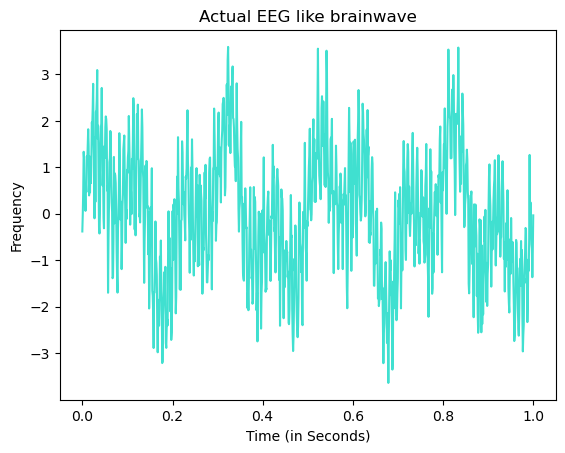

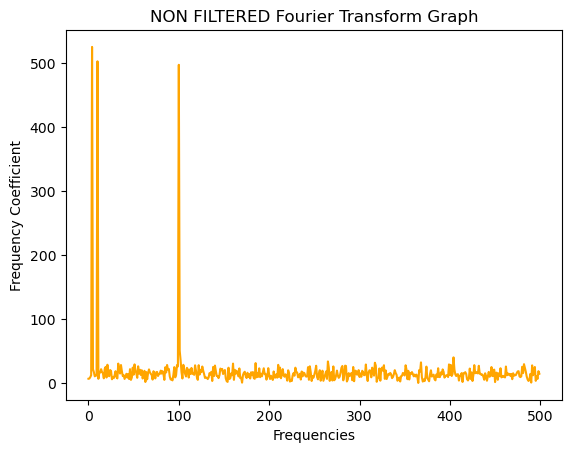

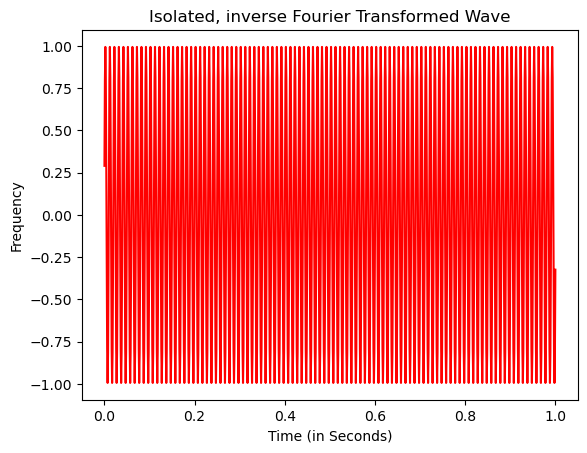

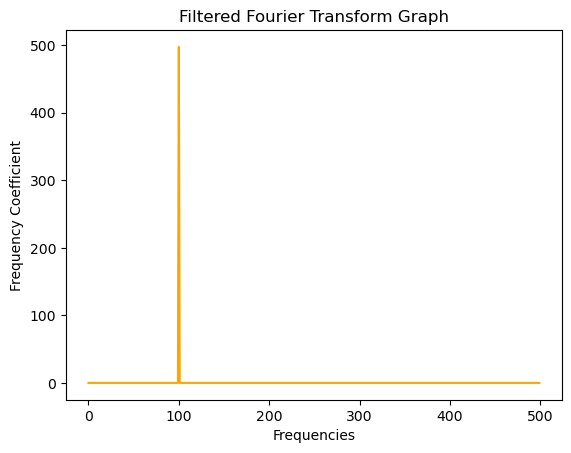

In [52]:
import numpy as np
from scipy import fft
import matplotlib.pyplot as plt
from Bio import SeqIO
high=100
low=99.9


time= np.linspace(0, 1, 1000)   
alpha_brainwave= np.sin(2 * np.pi * 10 * time)
theta_brainwave= np.sin(2* np.pi * 4 * time)
Gamma_waves=np.sin(2* np.pi * 100 * time) 
noise=np.random.normal(0, .5, 1000)

actual_brain_accurate_wave=alpha_brainwave+noise+theta_brainwave+Gamma_waves

plt.subplot(3, 1, 1)
plt.plot(time, actual_brain_accurate_wave, 'turquoise')





frequencies= fft.fftfreq(len(actual_brain_accurate_wave),1/1000)
magnitudes= np.abs(fft.fft(actual_brain_accurate_wave))
fft_signal=fft.fft(actual_brain_accurate_wave)
mask = ((abs(frequencies) >= low) & (abs(frequencies) <= high))
filtered_fft= (fft_signal * mask)
filtered_signal = fft.ifft(filtered_fft).real
filtered_magnitudes = np.abs(filtered_fft)


plt.subplot(3, 1, 2)
plt.plot(time, filtered_signal, 'red')


plt.subplot(3, 1, 3)
plt.axvline(x=8, color='red', linestyle='--', label='8 Hz Theta')
plt.legend()
plt.xlabel('Frequencies')
plt.ylabel('Frequency Coefficient')
plt.title('Fourier Transform Graph')
plt.plot(frequencies[:500], filtered_magnitudes[:500], 'orange')


plt.figure()
plt.plot(time, actual_brain_accurate_wave, 'turquoise')
plt.xlabel('Time (in Seconds)')
plt.ylabel('Frequency')
plt.title('Actual EEG like brainwave')
plt.show()

plt.figure()
plt.plot(frequencies[:500], magnitudes[:500], 'orange')
plt.xlabel('Frequencies')
plt.ylabel('Frequency Coefficient')
plt.title('NON FILTERED Fourier Transform Graph')
plt.show()

plt.figure()
plt.plot(time, filtered_signal, 'red')
plt.xlabel('Time (in Seconds)')
plt.ylabel('Frequency')
plt.title('Isolated, inverse Fourier Transformed Wave')
plt.show()

plt.figure()
plt.plot(frequencies[:500], filtered_magnitudes[:500], 'orange')
plt.xlabel('Frequencies')
plt.ylabel('Frequency Coefficient')
plt.title('Filtered Fourier Transform Graph')
plt.show()

